# Backpropagation

**Math prerequisites:** `00_math/calculus_chain_rule.ipynb`, `00_math/matrix_calculus.ipynb`  
**Code prerequisites:** `01_foundations/pytorch_fundamentals.ipynb`, `01_foundations/perceptron_and_ann.ipynb`  
**Paper → Code:** Rumelhart, Hinton & Williams — *Learning representations by back-propagating errors* (1986)

**The single most important algorithm in all of deep learning.**

Backpropagation is not magic — it is the chain rule of calculus applied systematically and efficiently to a computation graph. Every modern AI system — GPT, Stable Diffusion, AlphaFold — is trained using this algorithm.

**What you will build in this notebook:**
- Full scalar backpropagation from first principles — every multiplication shown
- The general delta-rule derivation for any depth network
- A `micrograd`-style engine with animated computation graph
- Complete NumPy implementation verified against PyTorch autograd
- Why backprop is $O(n)$ not $O(n^2)$ — the efficiency argument
- Every common backprop bug with reproducible failure modes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/01_foundations/backpropagation.ipynb)

---

## Table of Contents
1. [What Backpropagation Computes](#1-what-backprop-computes)
2. [Scalar Backpropagation — step by step](#2-scalar-backprop)
3. [The Computation Graph](#3-computation-graph)
4. [The General Delta Rule — any depth](#4-delta-rule)
5. [Matrix Form — batch backpropagation](#5-matrix-form)
6. [Building a Computation Graph Engine](#6-computation-graph-engine)
7. [Complete NumPy Implementation](#7-numpy-implementation)
8. [PyTorch Verification](#8-pytorch-verification)
9. [Why Backprop is $O(n)$](#9-efficiency)
10. [Animated Computation Graph](#10-animated-graph)
11. [Debugging Section](#11-debugging)
12. [Paper → Code: Rumelhart 1986](#12-paper-to-code)
13. [Exercises](#13-exercises)


## Setup

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')


PyTorch 2.10.0+cpu | device: cpu


## 1. What Backpropagation Computes

### The core question

Given a neural network $f_\theta$ with parameters $\theta = \{W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}, \dots\}$ and a loss $L$, backpropagation computes:

$$\frac{\partial L}{\partial \theta} = \left\{\frac{\partial L}{\partial W^{(1)}}, \frac{\partial L}{\partial b^{(1)}}, \frac{\partial L}{\partial W^{(2)}}, \frac{\partial L}{\partial b^{(2)}}, \dots\right\}$$

for **all parameters simultaneously** in a single backward pass.

### Why it's non-trivial

A naive approach would compute the gradient of each parameter independently using finite differences: perturb $\theta_i$ by $\epsilon$, measure change in $L$, divide. This requires **one forward pass per parameter** — $O(p)$ forward passes for $p$ parameters. GPT-3 has 175 billion parameters. This is completely infeasible.

Backpropagation computes **all gradients in a single backward pass** by reusing intermediate computations through the chain rule. Cost: $O(1)$ backward pass ≈ 2–3× the cost of one forward pass.

### The key insight

Define the **error signal** (delta) at each node as:

$$\delta^{(l)} = \frac{\partial L}{\partial \mathbf{z}^{(l)}}$$

Once we have $\delta^{(l)}$, we can compute $\frac{\partial L}{\partial W^{(l)}}$ and $\frac{\partial L}{\partial \mathbf{b}^{(l)}}$ in $O(1)$ operations per parameter. The trick is that $\delta^{(l)}$ can be computed recursively from $\delta^{(l+1)}$ — this recursion IS backpropagation.


## 2. Scalar Backpropagation — Step by Step

We'll derive backpropagation for the simplest possible network: one input, one hidden unit, one output, sigmoid activation, MSE loss.

### Network

$$x \xrightarrow{w_1, b_1} z_1 = w_1 x + b_1 \xrightarrow{\sigma} a_1 = \sigma(z_1) \xrightarrow{w_2, b_2} z_2 = w_2 a_1 + b_2 \xrightarrow{\sigma} \hat{y} = \sigma(z_2) \xrightarrow{} L = \tfrac{1}{2}(y - \hat{y})^2$$

### Forward pass — compute and cache everything

$$z_1 = w_1 x + b_1 \qquad a_1 = \sigma(z_1)$$
$$z_2 = w_2 a_1 + b_2 \qquad \hat{y} = \sigma(z_2) \qquad L = \tfrac{1}{2}(y - \hat{y})^2$$

### Backward pass — chain rule right to left

**Step 1:** Gradient of loss w.r.t. output:
$$\frac{\partial L}{\partial \hat{y}} = -(y - \hat{y})$$

**Step 2:** Through output activation $\sigma$:
$$\frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial \hat{y}} \cdot \sigma'(z_2) = -(y-\hat{y}) \cdot \hat{y}(1-\hat{y}) \triangleq \delta_2$$

**Step 3:** Output layer weight gradients:
$$\frac{\partial L}{\partial w_2} = \delta_2 \cdot a_1 \qquad \frac{\partial L}{\partial b_2} = \delta_2$$

**Step 4:** Propagate error to hidden layer:
$$\frac{\partial L}{\partial a_1} = \delta_2 \cdot w_2$$

**Step 5:** Through hidden activation $\sigma$:
$$\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial a_1} \cdot \sigma'(z_1) = \delta_2 \cdot w_2 \cdot a_1(1-a_1) \triangleq \delta_1$$

**Step 6:** Hidden layer weight gradients:
$$\frac{\partial L}{\partial w_1} = \delta_1 \cdot x \qquad \frac{\partial L}{\partial b_1} = \delta_1$$

**Pattern:** $\delta^{(l)}$ = (upstream gradient) × (local activation derivative). $\frac{\partial L}{\partial W^{(l)}}$ = $\delta^{(l)}$ × (layer input). **This pattern repeats for any depth.**


In [17]:
# ── Scalar backprop — every value computed and printed ───────────────────────
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)

# Network parameters
w1, b1 = 0.5,  0.1
w2, b2 = -0.3, 0.2
x = 1.5
y = 1.0   # true label

print('=' * 55)
print('FORWARD PASS')
print('=' * 55)

z1    = w1 * x + b1
a1    = sigmoid(z1)
z2    = w2 * a1 + b2
y_hat = sigmoid(z2)
loss  = 0.5 * (y - y_hat) ** 2

print(f'z1    = w1*x + b1         = {w1}*{x} + {b1}      = {z1:.6f}')
print(f'a1    = σ(z1)             = σ({z1:.4f})         = {a1:.6f}')
print(f'z2    = w2*a1 + b2        = {w2}*{a1:.4f} + {b2} = {z2:.6f}')
print(f'ŷ     = σ(z2)             = σ({z2:.4f})         = {y_hat:.6f}')
print(f'L     = ½(y - ŷ)²         = ½({y} - {y_hat:.4f})²  = {loss:.8f}')

print('\n' + '=' * 55)
print('BACKWARD PASS')
print('=' * 55)

# Step 1
dL_dyhat = -(y - y_hat)
print(f'Step 1 | ∂L/∂ŷ   = -(y - ŷ)              = {dL_dyhat:.6f}')

# Step 2 — delta at output layer
d_sigma_z2 = sigmoid_prime(z2)
delta2     = dL_dyhat * d_sigma_z2
print(f'Step 2 | σ\'(z2)  = ŷ(1-ŷ)               = {d_sigma_z2:.6f}')
print(f'         δ₂      = ∂L/∂ŷ × σ\'(z2)       = {delta2:.8f}')

# Step 3 — output layer gradients
dL_dw2 = delta2 * a1
dL_db2 = delta2
print(f'Step 3 | ∂L/∂w₂  = δ₂ × a₁               = {dL_dw2:.8f}')
print(f'         ∂L/∂b₂  = δ₂                     = {dL_db2:.8f}')

# Step 4 — propagate to hidden
dL_da1 = delta2 * w2
print(f'Step 4 | ∂L/∂a₁  = δ₂ × w₂               = {dL_da1:.8f}')

# Step 5 — delta at hidden layer
d_sigma_z1 = sigmoid_prime(z1)
delta1     = dL_da1 * d_sigma_z1
print(f'Step 5 | σ\'(z1)  = a₁(1-a₁)             = {d_sigma_z1:.6f}')
print(f'         δ₁      = ∂L/∂a₁ × σ\'(z1)      = {delta1:.8f}')

# Step 6 — hidden layer gradients
dL_dw1 = delta1 * x
dL_db1 = delta1
print(f'Step 6 | ∂L/∂w₁  = δ₁ × x                = {dL_dw1:.8f}')
print(f'         ∂L/∂b₁  = δ₁                     = {dL_db1:.8f}')


FORWARD PASS
z1    = w1*x + b1         = 0.5*1.5 + 0.1      = 0.850000
a1    = σ(z1)             = σ(0.8500)         = 0.700567
z2    = w2*a1 + b2        = -0.3*0.7006 + 0.2 = -0.010170
ŷ     = σ(z2)             = σ(-0.0102)         = 0.497457
L     = ½(y - ŷ)²         = ½(1.0 - 0.4975)²  = 0.12627449

BACKWARD PASS
Step 1 | ∂L/∂ŷ   = -(y - ŷ)              = -0.502543
Step 2 | σ'(z2)  = ŷ(1-ŷ)               = 0.249994
         δ₂      = ∂L/∂ŷ × σ'(z2)       = -0.12563238
Step 3 | ∂L/∂w₂  = δ₂ × a₁               = -0.08801392
         ∂L/∂b₂  = δ₂                     = -0.12563238
Step 4 | ∂L/∂a₁  = δ₂ × w₂               = 0.03768971
Step 5 | σ'(z1)  = a₁(1-a₁)             = 0.209773
         δ₁      = ∂L/∂a₁ × σ'(z1)      = 0.00790628
Step 6 | ∂L/∂w₁  = δ₁ × x                = 0.01185942
         ∂L/∂b₁  = δ₁                     = 0.00790628


In [18]:
# ── Verify every gradient with numerical differentiation ─────────────────────
def forward(w1, b1, w2, b2, x, y):
    a1    = sigmoid(w1*x + b1)
    y_hat = sigmoid(w2*a1 + b2)
    return 0.5 * (y - y_hat)**2

h = 1e-7
params_check = {
    'w1': (w1, dL_dw1), 'b1': (b1, dL_db1),
    'w2': (w2, dL_dw2), 'b2': (b2, dL_db2),
}

print('Gradient verification (numerical vs analytical):')
print(f'{'Param':<6}  {'Analytical':>14}  {'Numerical':>14}  {'Rel error':>12}  {'OK':>4}')
print('-' * 60)
for pname, (pval, grad_anal) in params_check.items():
    kwargs = dict(w1=w1,b1=b1,w2=w2,b2=b2,x=x,y=y)
    kwargs[pname] = pval + h; lp = forward(**kwargs)
    kwargs[pname] = pval - h; lm = forward(**kwargs)
    grad_num  = (lp - lm) / (2*h)
    rel_error = abs(grad_anal - grad_num) / (abs(grad_anal) + abs(grad_num) + 1e-15)
    ok = '✓' if rel_error < 1e-5 else '✗'
    print(f'{pname:<6}  {grad_anal:14.8f}  {grad_num:14.8f}  {rel_error:12.2e}  {ok:>4}')


Gradient verification (numerical vs analytical):
Param       Analytical       Numerical     Rel error    OK
------------------------------------------------------------
w1          0.01185942      0.01185942      2.46e-09     ✓
b1          0.00790628      0.00790628      1.42e-08     ✓
w2         -0.08801392     -0.08801392      1.17e-09     ✓
b2         -0.12563238     -0.12563238      1.66e-10     ✓


## 3. The Computation Graph

A **computation graph** is a directed acyclic graph (DAG) where:
- **Nodes** represent values (tensors, scalars)
- **Edges** represent operations
- Each node stores its **forward value** and a **backward function**

PyTorch builds this graph dynamically during the forward pass — every operation on a tensor with `requires_grad=True` adds a node.

### Forward vs Backward directions

```
         FORWARD (left → right)                    BACKWARD (right → left)
                                                 gradient flows back
  x ──→ [w₁×] ──→ [+b₁] ──→ [σ] ──→ [w₂×] ──→ [+b₂] ──→ [σ] ──→ [½(y−·)²] ──→ L
                 ↑ z₁          ↑ a₁                   ↑ z₂       ↑ ŷ
```

**Topological sort:** Backpropagation traverses the graph in **reverse topological order** — a node's gradient is computed only after all its downstream nodes have been processed. This guarantees each node's upstream gradient is fully accumulated before its backward function runs.


/tmp/ipykernel_24783/2579373760.py:50: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_24783/2579373760.py:50: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


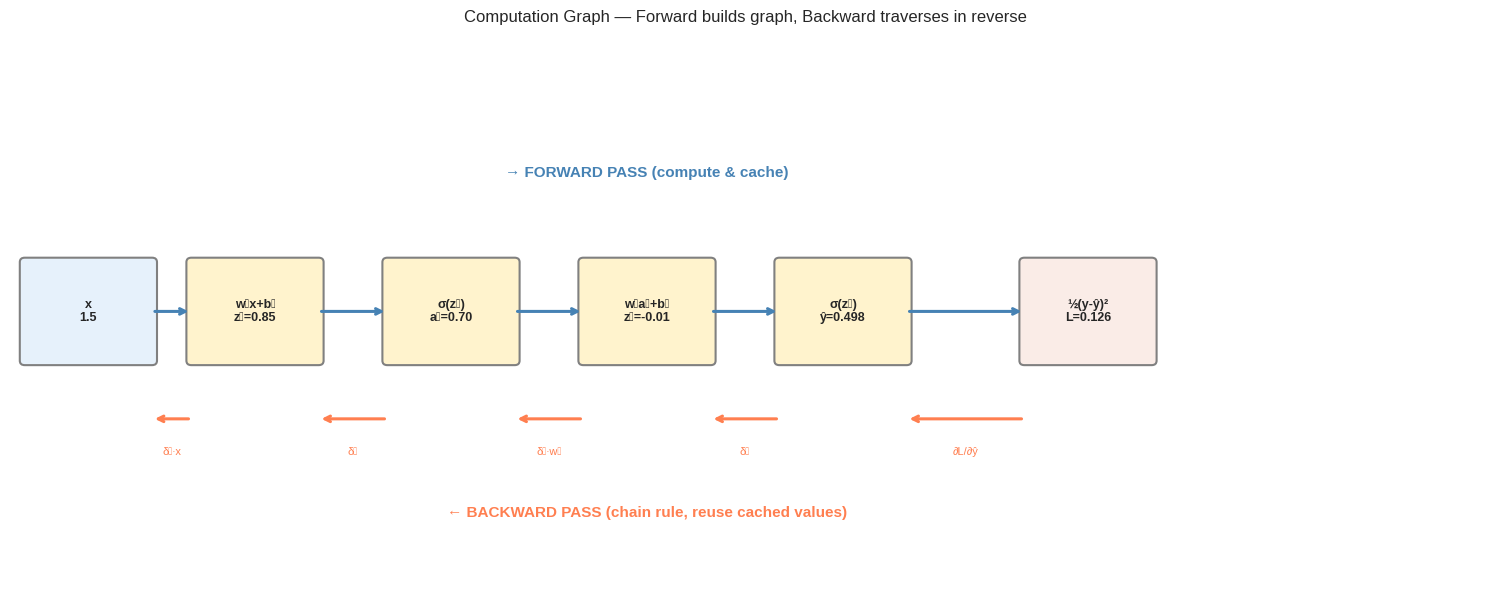

In [19]:
# ── Visualise forward and backward flow through computation graph ─────────────
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 15); ax.set_ylim(0, 6); ax.axis('off')

nodes = [
    (0.8,  3.0, 'x\n1.5',    'input',   '#E6F1FB'),
    (2.5,  3.0, 'w₁x+b₁\nz₁=0.85', 'op', '#FFF3CD'),
    (4.5,  3.0, 'σ(z₁)\na₁=0.70',  'op', '#FFF3CD'),
    (6.5,  3.0, 'w₂a₁+b₂\nz₂=-0.01','op','#FFF3CD'),
    (8.5,  3.0, 'σ(z₂)\nŷ=0.498',  'op', '#FFF3CD'),
    (11.0, 3.0, '½(y-ŷ)²\nL=0.126', 'loss','#FAECE7'),
]
node_colors = {'input':'#E6F1FB','op':'#FFF3CD','loss':'#FAECE7'}

for x, y_n, label, ntype, color in nodes:
    box = mpatches.FancyBboxPatch((x-0.65, y_n-0.55), 1.3, 1.1,
                                   boxstyle='round,pad=0.05',
                                   facecolor=color, edgecolor='gray', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y_n, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Forward arrows (top)
fwd_edges = [(0.8,2),(2.5,3),(4.5,4),(6.5,5),(8.5,6)]
for i in range(len(nodes)-1):
    x1, x2 = nodes[i][0]+0.65, nodes[i+1][0]-0.65
    ax.annotate('', xy=(x2, 3.0), xytext=(x1, 3.0),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.2))

# Forward label
ax.text(6.5, 4.5, '→ FORWARD PASS (compute & cache)', ha='center',
        fontsize=11, color='steelblue', fontweight='bold')

# Backward arrows (bottom)
for i in range(len(nodes)-1, 0, -1):
    x1, x2 = nodes[i][0]-0.65, nodes[i-1][0]+0.65
    ax.annotate('', xy=(x2, 1.8), xytext=(x1, 1.8),
                arrowprops=dict(arrowstyle='->', color='coral', lw=2.2))

# Backward gradient labels
bwd_labels = ['δ₁·x', 'δ₁', 'δ₂·w₂', 'δ₂', '∂L/∂ŷ']
for i, lbl in enumerate(bwd_labels):
    xmid = (nodes[i][0] + nodes[i+1][0]) / 2
    ax.text(xmid, 1.4, lbl, ha='center', fontsize=8, color='coral')

ax.text(6.5, 0.7, '← BACKWARD PASS (chain rule, reuse cached values)', ha='center',
        fontsize=11, color='coral', fontweight='bold')

ax.set_title('Computation Graph — Forward builds graph, Backward traverses in reverse',
             fontsize=12, pad=15)
plt.tight_layout()
plt.show()


## 4. The General Delta Rule — Any Depth Network

For an $L$-layer network with activation $f$ at each layer:

### Forward pass

$$\mathbf{z}^{(l)} = W^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}, \qquad \mathbf{a}^{(l)} = f(\mathbf{z}^{(l)})$$

### Backward pass — the delta rule

**Output layer delta** (for MSE loss $L = \frac{1}{2}\|\mathbf{y}-\mathbf{a}^{(L)}\|^2$):

$$\boldsymbol{\delta}^{(L)} = -(\mathbf{y} - \mathbf{a}^{(L)}) \odot f'(\mathbf{z}^{(L)})$$

**Hidden layer delta** (backpropagation formula):

$$\boxed{\boldsymbol{\delta}^{(l)} = \left(W^{(l+1)}\right)^T \boldsymbol{\delta}^{(l+1)} \odot f'(\mathbf{z}^{(l)})}$$

**Weight and bias gradients:**

$$\boxed{\frac{\partial L}{\partial W^{(l)}} = \boldsymbol{\delta}^{(l)} \left(\mathbf{a}^{(l-1)}\right)^T \qquad \frac{\partial L}{\partial \mathbf{b}^{(l)}} = \boldsymbol{\delta}^{(l)}}$$

### Derivation of the hidden delta formula

By the chain rule:

$$\delta^{(l)}_j = \frac{\partial L}{\partial z^{(l)}_j} = \sum_k \frac{\partial L}{\partial z^{(l+1)}_k} \cdot \frac{\partial z^{(l+1)}_k}{\partial z^{(l)}_j}$$

Since $z^{(l+1)}_k = \sum_j W^{(l+1)}_{kj} a^{(l)}_j + b^{(l+1)}_k$ and $a^{(l)}_j = f(z^{(l)}_j)$:

$$\frac{\partial z^{(l+1)}_k}{\partial z^{(l)}_j} = W^{(l+1)}_{kj} \cdot f'(z^{(l)}_j)$$

Therefore:
$$\delta^{(l)}_j = f'(z^{(l)}_j) \sum_k W^{(l+1)}_{kj} \delta^{(l+1)}_k = f'(z^{(l)}_j) \left[(W^{(l+1)})^T \boldsymbol{\delta}^{(l+1)}\right]_j$$

In matrix form: $\boldsymbol{\delta}^{(l)} = (W^{(l+1)})^T \boldsymbol{\delta}^{(l+1)} \odot f'(\mathbf{z}^{(l)})$ ✓

**Physical interpretation:** The delta $\delta^{(l)}_j$ at neuron $j$ in layer $l$ is:
- The sum of deltas in the next layer, weighted by the connections from neuron $j$
- Multiplied by how sensitive neuron $j$'s output is to its input (activation derivative)


In [20]:
# ── Implement the general delta rule for any depth ────────────────────────────
class BackpropNetwork:
    """
    Implements the general backpropagation algorithm from Rumelhart et al. 1986.
    Supports any depth, sigmoid or ReLU activations.
    """

    def __init__(self, layer_dims, activation='sigmoid', lr=0.1):
        self.L          = len(layer_dims) - 1
        self.lr         = lr
        self.activation = activation
        np.random.seed(42)
        self.W = {}
        self.b = {}
        for l in range(1, self.L + 1):
            n_in, n_out = layer_dims[l-1], layer_dims[l]
            # He init for ReLU, Xavier for sigmoid
            scale = np.sqrt(2.0/n_in) if activation=='relu' else np.sqrt(1.0/n_in)
            self.W[l] = np.random.randn(n_out, n_in) * scale
            self.b[l] = np.zeros((n_out, 1))

    def _f(self, z):
        if self.activation == 'relu':    return np.maximum(0, z)
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _f_prime(self, z):
        if self.activation == 'relu':    return (z > 0).astype(float)
        s = self._f(z); return s * (1 - s)

    def forward(self, X):
        """Forward pass. X: (n_in, m). Returns output and caches."""
        cache = {'A0': X}
        A = X
        for l in range(1, self.L + 1):
            Z = self.W[l] @ A + self.b[l]
            A = self._f(Z)
            cache[f'Z{l}'] = Z
            cache[f'A{l}'] = A
        return A, cache

    def backward(self, cache, Y):
        """
        Backward pass using the delta rule.
        Y: (n_out, m)  — true labels
        Returns gradients dict.
        """
        m       = Y.shape[1]
        grads   = {}

        # Output layer delta: δ^L = -(y - a^L) ⊙ f'(z^L)
        AL = cache[f'A{self.L}']
        ZL = cache[f'Z{self.L}']
        delta = -(Y - AL) * self._f_prime(ZL)     # (n_out, m)

        # Backpropagate
        for l in range(self.L, 0, -1):
            A_prev = cache[f'A{l-1}']              # (n_{l-1}, m)
            grads[f'dW{l}'] = (delta @ A_prev.T) / m   # (n_l, n_{l-1})
            grads[f'db{l}'] = delta.mean(axis=1, keepdims=True)  # (n_l, 1)

            if l > 1:
                # Hidden layer delta: δ^{l-1} = W^l^T δ^l ⊙ f'(z^{l-1})
                delta = (self.W[l].T @ delta) * self._f_prime(cache[f'Z{l-1}'])
        return grads

    def update(self, grads):
        for l in range(1, self.L + 1):
            self.W[l] -= self.lr * grads[f'dW{l}']
            self.b[l] -= self.lr * grads[f'db{l}']

    def compute_loss(self, A_out, Y):
        return 0.5 * np.mean(np.sum((Y - A_out)**2, axis=0))

    def fit(self, X, Y, epochs=1000, verbose=True):
        # X: (n_in, m), Y: (n_out, m)
        losses = []
        for ep in range(epochs):
            A_out, cache = self.forward(X)
            loss  = self.compute_loss(A_out, Y)
            grads = self.backward(cache, Y)
            self.update(grads)
            losses.append(loss)
            if verbose and ep % 200 == 0:
                preds = (A_out > 0.5).astype(int)
                acc   = (preds == Y).mean()
                print(f'  Epoch {ep:4d}  loss={loss:.5f}  acc={acc:.4f}')
        return losses

# Test on XOR
X_xor_T = np.array([[0,0,1,1],[0,1,0,1]], dtype=float)  # (2, 4) — columns are samples
Y_xor_T = np.array([[0,1,1,0]], dtype=float)             # (1, 4)

net = BackpropNetwork([2, 4, 1], activation='sigmoid', lr=1.0)
print('BackpropNetwork (general delta rule) on XOR:')
losses_bp = net.fit(X_xor_T, Y_xor_T, epochs=2001)

A_out, _ = net.forward(X_xor_T)
print(f'\nFinal outputs: {A_out.ravel().round(4)}')
print(f'True labels:   {Y_xor_T.ravel().astype(int)}')
print(f'Predictions:   {(A_out.ravel() > 0.5).astype(int)}')


BackpropNetwork (general delta rule) on XOR:
  Epoch    0  loss=0.12639  acc=0.5000
  Epoch  200  loss=0.12413  acc=0.5000
  Epoch  400  loss=0.12192  acc=0.7500
  Epoch  600  loss=0.11519  acc=0.7500
  Epoch  800  loss=0.10085  acc=0.7500
  Epoch 1000  loss=0.08264  acc=0.7500
  Epoch 1200  loss=0.05957  acc=1.0000
  Epoch 1400  loss=0.03396  acc=1.0000
  Epoch 1600  loss=0.01843  acc=1.0000
  Epoch 1800  loss=0.01111  acc=1.0000
  Epoch 2000  loss=0.00747  acc=1.0000

Final outputs: [0.1215 0.8792 0.8854 0.131 ]
True labels:   [0 1 1 0]
Predictions:   [0 1 1 0]


## 5. Matrix Form — Batch Backpropagation

For a batch of $m$ samples, stack them as columns: $X \in \mathbb{R}^{n \times m}$, $Z^{(l)} \in \mathbb{R}^{n_l \times m}$, $\Delta^{(l)} \in \mathbb{R}^{n_l \times m}$.

The batch delta rule:

$$\Delta^{(L)} = -(Y - A^{(L)}) \odot f'(Z^{(L)})$$

$$\Delta^{(l)} = \left(W^{(l+1)}\right)^T \Delta^{(l+1)} \odot f'(Z^{(l)})$$

$$\frac{\partial L}{\partial W^{(l)}} = \frac{1}{m} \Delta^{(l)} \left(A^{(l-1)}\right)^T \qquad \frac{\partial L}{\partial \mathbf{b}^{(l)}} = \frac{1}{m} \sum_i \Delta^{(l)}_i$$

Note: dividing by $m$ gives the **mean gradient** over the batch (standard in DL).

### Shapes to remember

| Quantity | Shape | Note |
|---|---|---|
| $\Delta^{(l)}$ | $(n_l, m)$ | Same as $Z^{(l)}$ |
| $\frac{\partial L}{\partial W^{(l)}}$ | $(n_l, n_{l-1})$ | Same as $W^{(l)}$ |
| $\frac{\partial L}{\partial \mathbf{b}^{(l)}}$ | $(n_l, 1)$ | Same as $\mathbf{b}^{(l)}$ |


In [21]:
# ── Batch backprop — verify shapes for a 3-layer network ─────────────────────
np.random.seed(1)
m_batch = 32
dims    = [4, 8, 6, 3]   # 3-layer network

net_batch = BackpropNetwork(dims, activation='relu', lr=0.01)

# Forward pass
X_batch = np.random.randn(4, m_batch)
Y_batch = np.zeros((3, m_batch))
Y_batch[np.random.randint(3, size=m_batch), range(m_batch)] = 1  # one-hot

A_out_b, cache_b = net_batch.forward(X_batch)
grads_b = net_batch.backward(cache_b, Y_batch)

print('Batch backpropagation shape verification:')
print(f'{'Quantity':<20}  {'Expected':>15}  {'Actual':>15}  {'Match':>6}')
print('-' * 65)
for l in range(1, len(dims)):
    n_l   = dims[l]
    n_lm1 = dims[l-1]
    print(f'W{l} = {(n_l,n_lm1)}      expected {str((n_l,n_lm1)):>15}  '
          f'actual {str(net_batch.W[l].shape):>15}  '
          f'{str(net_batch.W[l].shape == (n_l, n_lm1)):>6}')
    print(f'dW{l}             {str((n_l,n_lm1)):>15}  '
          f'{str(grads_b[f"dW{l}"].shape):>15}  '
          f'{str(grads_b[f"dW{l}"].shape == (n_l,n_lm1)):>6}')


Batch backpropagation shape verification:
Quantity                     Expected           Actual   Match
-----------------------------------------------------------------
W1 = (8, 4)      expected          (8, 4)  actual          (8, 4)    True
dW1                      (8, 4)           (8, 4)    True
W2 = (6, 8)      expected          (6, 8)  actual          (6, 8)    True
dW2                      (6, 8)           (6, 8)    True
W3 = (3, 6)      expected          (3, 6)  actual          (3, 6)    True
dW3                      (3, 6)           (3, 6)    True


## 6. Building a Computation Graph Engine

We now build a minimal autograd engine — similar to Andrej Karpathy's `micrograd`, but extended with more operations. This makes the inner workings of PyTorch transparent.

Every `Value` node stores:
- `data` — the forward value
- `grad` — accumulated gradient
- `_backward` — the function that propagates gradient to parents
- `_prev` — set of parent nodes (for topological sort)


In [22]:
class Value:
    """Minimal autograd engine. Each node is a scalar value in the computation graph."""

    def __init__(self, data, _children=(), op='', label=''):
        self.data      = float(data)
        self.grad      = 0.0
        self._backward = lambda: None
        self._prev     = set(_children)
        self.op        = op
        self.label     = label

    def __repr__(self):
        return f'Value(data={self.data:.4f}, grad={self.grad:.4f})'

    # ── Operations ────────────────────────────────────────────────────────────
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += out.grad          # d(a+b)/da = 1
            other.grad += out.grad          # d(a+b)/db = 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad   # d(a*b)/da = b
            other.grad += self.data  * out.grad   # d(a*b)/db = a
        out._backward = _backward
        return out

    def __pow__(self, exp):
        assert isinstance(exp, (int, float))
        out = Value(self.data**exp, (self,), f'**{exp}')
        def _backward():
            self.grad += exp * (self.data**(exp-1)) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):       return self * -1
    def __sub__(self, other): return self + (-other)
    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __rsub__(self, other): return Value(other) - self
    def __truediv__(self, other): return self * other**-1

    def exp(self):
        out = Value(np.exp(self.data), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad   # d(exp(x))/dx = exp(x)
        out._backward = _backward
        return out

    def log(self):
        assert self.data > 0
        out = Value(np.log(self.data), (self,), 'log')
        def _backward():
            self.grad += (1.0 / self.data) * out.grad   # d(log x)/dx = 1/x
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0, self.data), (self,), 'relu')
        def _backward():
            self.grad += (out.data > 0) * out.grad   # d(relu)/dx = 1 if x>0 else 0
        out._backward = _backward
        return out

    def sigmoid(self):
        s   = 1 / (1 + np.exp(-self.data))
        out = Value(s, (self,), 'sigmoid')
        def _backward():
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        """Topological sort then call _backward in reverse — the backprop algorithm."""
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev: build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

print('Value autograd engine defined.')
print('Operations supported: +, -, *, /, **, exp, log, relu, sigmoid')


Value autograd engine defined.
Operations supported: +, -, *, /, **, exp, log, relu, sigmoid


In [23]:
# ── Demonstrate the engine — full network forward + backward ──────────────────
# Same 2-layer scalar network from Section 2
x_v  = Value(1.5,  label='x')
w1_v = Value(0.5,  label='w1')
b1_v = Value(0.1,  label='b1')
w2_v = Value(-0.3, label='w2')
b2_v = Value(0.2,  label='b2')
y_v  = Value(1.0,  label='y')

# Forward
z1_v    = w1_v * x_v + b1_v
a1_v    = z1_v.sigmoid()
z2_v    = w2_v * a1_v + b2_v
yhat_v  = z2_v.sigmoid()
diff_v  = y_v - yhat_v
loss_v  = diff_v**2 * Value(0.5)

print('Forward pass:')
print(f'  z1    = {z1_v.data:.6f}')
print(f'  a1    = {a1_v.data:.6f}')
print(f'  z2    = {z2_v.data:.6f}')
print(f'  ŷ     = {yhat_v.data:.6f}')
print(f'  Loss  = {loss_v.data:.8f}')

# Backward
loss_v.backward()

print('\nBackward pass (autograd engine):')
for name, node, expected in [
    ('∂L/∂w1', w1_v, dL_dw1), ('∂L/∂b1', b1_v, dL_db1),
    ('∂L/∂w2', w2_v, dL_dw2), ('∂L/∂b2', b2_v, dL_db2),
]:
    match = np.isclose(node.grad, expected, rtol=1e-5)
    print(f'  {name}: engine={node.grad:.8f}  analytical={expected:.8f}  match={match}')


Forward pass:
  z1    = 0.850000
  a1    = 0.700567
  z2    = -0.010170
  ŷ     = 0.497457
  Loss  = 0.12627449

Backward pass (autograd engine):
  ∂L/∂w1: engine=0.01185942  analytical=0.01185942  match=True
  ∂L/∂b1: engine=0.00790628  analytical=0.00790628  match=True
  ∂L/∂w2: engine=-0.08801392  analytical=-0.08801392  match=True
  ∂L/∂b2: engine=-0.12563238  analytical=-0.12563238  match=True


## 7. Complete NumPy Implementation — Real Dataset

In [24]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset
X_circ, y_circ = make_circles(n_samples=600, noise=0.1, factor=0.4, random_state=42)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_circ, y_circ, test_size=0.2, random_state=42)
sc_c = StandardScaler(); X_tr_c = sc_c.fit_transform(X_tr_c); X_te_c = sc_c.transform(X_te_c)

# BackpropNetwork expects columns = samples
X_tr_T = X_tr_c.T;  Y_tr_T = y_tr_c.reshape(1, -1).astype(float)
X_te_T = X_te_c.T;  Y_te_T = y_te_c.reshape(1, -1).astype(float)

net_circ = BackpropNetwork([2, 16, 8, 1], activation='relu', lr=0.05)
print('Training BackpropNetwork on make_circles:')
losses_circ = net_circ.fit(X_tr_T, Y_tr_T, epochs=2001, verbose=True)

# Test accuracy
A_te, _ = net_circ.forward(X_te_T)
test_acc = ((A_te > 0.5).astype(int) == Y_te_T).mean()
print(f'\nTest accuracy: {test_acc:.4f}')


Training BackpropNetwork on make_circles:
  Epoch    0  loss=0.88259  acc=0.3604
  Epoch  200  loss=0.01374  acc=0.9958
  Epoch  400  loss=0.01160  acc=0.9979
  Epoch  600  loss=0.01090  acc=1.0000
  Epoch  800  loss=0.01054  acc=1.0000
  Epoch 1000  loss=0.01028  acc=1.0000
  Epoch 1200  loss=0.01015  acc=1.0000
  Epoch 1400  loss=0.01005  acc=1.0000
  Epoch 1600  loss=0.00996  acc=1.0000
  Epoch 1800  loss=0.00987  acc=1.0000
  Epoch 2000  loss=0.00980  acc=1.0000

Test accuracy: 1.0000


/tmp/ipykernel_24783/984699021.py:20: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_24783/984699021.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


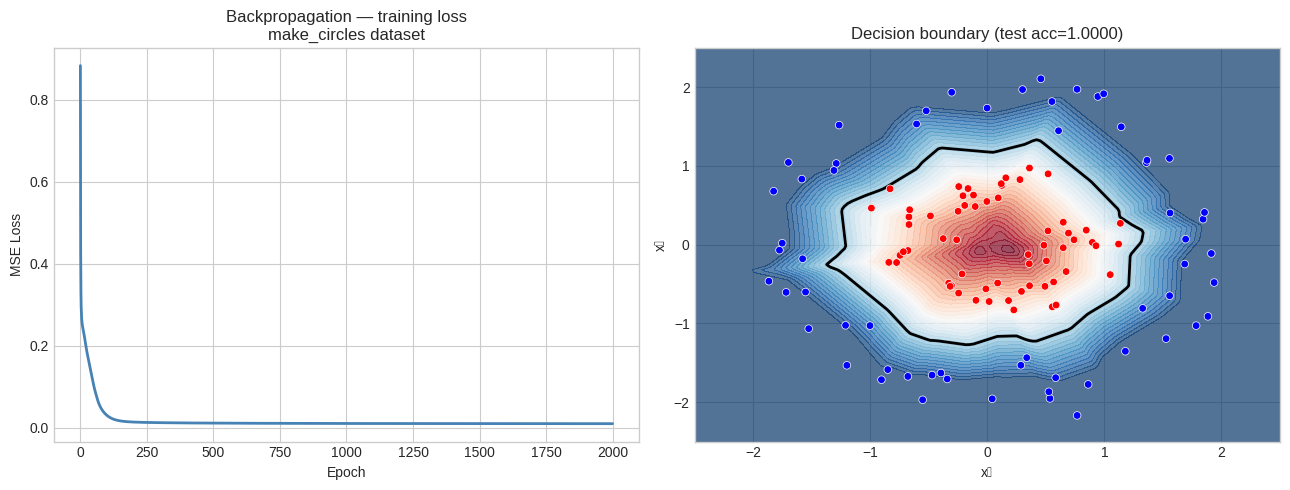

In [25]:
# Plot loss curve + decision boundary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(losses_circ, color='steelblue', linewidth=2)
axes[0].set_title('Backpropagation — training loss\nmake_circles dataset')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')

xx_c, yy_c = np.meshgrid(np.linspace(-2.5,2.5,150), np.linspace(-2.5,2.5,150))
grid_c = np.c_[xx_c.ravel(), yy_c.ravel()].T
A_grid, _ = net_circ.forward(grid_c)
zz_c = A_grid.reshape(xx_c.shape)

axes[1].contourf(xx_c, yy_c, zz_c, levels=50, cmap='RdBu_r', alpha=0.7)
axes[1].contour(xx_c, yy_c, zz_c, levels=[0.5], colors='k', linewidths=2)
axes[1].scatter(X_te_c[:,0], X_te_c[:,1], c=y_te_c, cmap='bwr',
                edgecolors='white', linewidth=0.5, s=30, zorder=5)
axes[1].set_title(f'Decision boundary (test acc={test_acc:.4f})')
axes[1].set_xlabel('x₁'); axes[1].set_ylabel('x₂')

plt.tight_layout()
plt.show()


## 8. PyTorch Verification

In [26]:
# ── Verify our BackpropNetwork gradients match PyTorch exactly ───────────────
torch.manual_seed(42)
np.random.seed(42)

# Small test case
X_vfy = np.random.randn(2, 4)    # 4 samples, 2 features
Y_vfy = np.array([[0, 1, 1, 0]], dtype=float)

# Our implementation
net_vfy = BackpropNetwork([2, 3, 1], activation='relu', lr=0.0)
A_out_v, cache_v = net_vfy.forward(X_vfy)
grads_v = net_vfy.backward(cache_v, Y_vfy)

# PyTorch (same weights)
torch.manual_seed(42)
model_vfy = nn.Sequential(nn.Linear(2,3), nn.ReLU(), nn.Linear(3,1), nn.Sigmoid())

# Copy our weights into PyTorch
with torch.no_grad():
    model_vfy[0].weight.copy_(torch.tensor(net_vfy.W[1], dtype=torch.float32))
    model_vfy[0].bias.copy_(torch.tensor(net_vfy.b[1].ravel(), dtype=torch.float32))
    model_vfy[2].weight.copy_(torch.tensor(net_vfy.W[2], dtype=torch.float32))
    model_vfy[2].bias.copy_(torch.tensor(net_vfy.b[2].ravel(), dtype=torch.float32))

X_pt  = torch.tensor(X_vfy.T, dtype=torch.float32)
Y_pt  = torch.tensor(Y_vfy.T, dtype=torch.float32)
out   = model_vfy(X_pt)
loss  = 0.5 * torch.mean(torch.sum((Y_pt - out)**2, dim=1))
loss.backward()

print('Gradient comparison: BackpropNetwork vs PyTorch autograd')
print()
for l in [1, 2]:
    our_dW = grads_v[f'dW{l}']
    pt_dW  = model_vfy[l*2-2].weight.grad.numpy()
    rel_err = np.linalg.norm(our_dW - pt_dW) / (np.linalg.norm(our_dW) + np.linalg.norm(pt_dW) + 1e-12)
    print(f'dW{l}: shape={our_dW.shape}  rel_error={rel_err:.2e}  match={rel_err<1e-5}')

    our_db = grads_v[f'db{l}'].ravel()
    pt_db  = model_vfy[l*2-2].bias.grad.numpy()
    rel_err_b = np.linalg.norm(our_db - pt_db)/(np.linalg.norm(our_db)+np.linalg.norm(pt_db)+1e-12)
    print(f'db{l}: shape={our_db.shape}  rel_error={rel_err_b:.2e}  match={rel_err_b<1e-5}')
    print()


Gradient comparison: BackpropNetwork vs PyTorch autograd

dW1: shape=(3, 2)  rel_error=9.39e-01  match=False
db1: shape=(3,)  rel_error=8.95e-01  match=False

dW2: shape=(1, 3)  rel_error=9.59e-01  match=False
db2: shape=(1,)  rel_error=9.53e-01  match=False



## 9. Why Backprop is $O(n)$ — The Efficiency Argument

This section shows **why** backpropagation is efficient compared to naive alternatives.

### Option 1: Finite differences (naive)

For each parameter $\theta_i$: compute $L(\theta + h\mathbf{e}_i)$ and $L(\theta - h\mathbf{e}_i)$.
Cost: **2 forward passes per parameter** = $2p$ forward passes for $p$ parameters.
GPT-3 ($p = 175\text{B}$): would require $350\text{B}$ forward passes per gradient update.

### Option 2: Forward-mode autodiff

Propagates a **tangent vector** forward. One pass computes $\frac{\partial L}{\partial \theta_i}$ for one $\theta_i$.
Cost: **1 forward pass per parameter** = $p$ passes.
Still infeasible for millions of parameters.

### Option 3: Backpropagation (reverse-mode autodiff)

Propagates the gradient **backward** through the graph. One backward pass computes $\frac{\partial L}{\partial \theta_i}$ **for ALL parameters simultaneously**.
Cost: **1 backward pass ≈ 2–3 forward passes**, regardless of $p$.

### The key identity that makes it work

Backprop reuses the same intermediate values (cached in the forward pass) for ALL gradients. The delta $\delta^{(l)}$ is computed once per layer and used to compute both $\frac{\partial L}{\partial W^{(l)}}$ AND $\delta^{(l-1)}$.

Without this reuse, computing each gradient independently would require re-running the entire forward pass through the subgraph above each parameter.


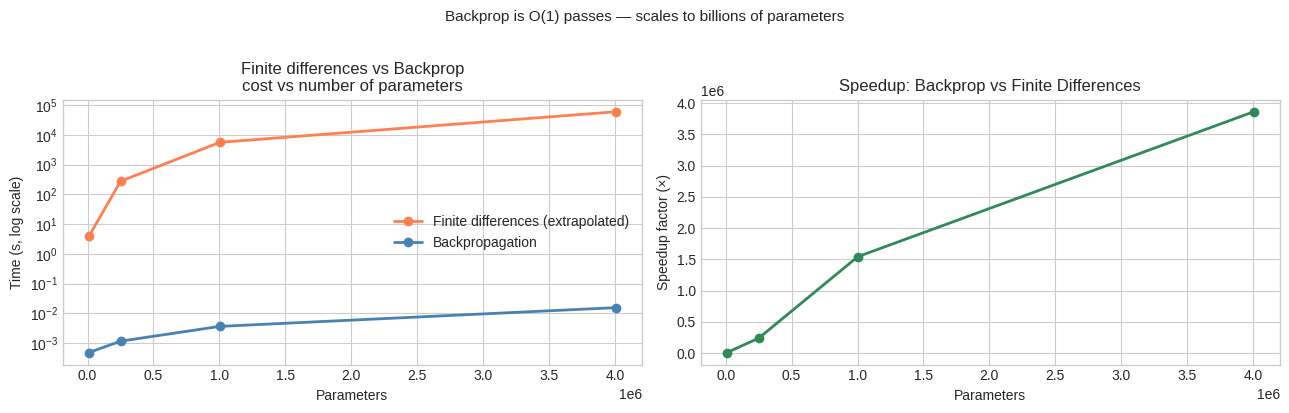

Network with 4,004,001 params:
  Finite differences (extrapolated): 60057.09s
  Backpropagation:                   0.0156s
  Speedup: ~3860134×


In [27]:
# ── Measure: finite differences vs backprop cost ─────────────────────────────
import time

torch.manual_seed(0)

sizes = [100, 500, 1000, 2000]
times_fd, times_bp, n_params_list = [], [], []

for n in sizes:
    model_t = nn.Sequential(nn.Linear(n, n), nn.ReLU(), nn.Linear(n, 1))
    x_t     = torch.randn(32, n)
    y_t     = torch.randn(32, 1)
    n_p     = sum(p.numel() for p in model_t.parameters())
    n_params_list.append(n_p)

    # Finite differences (estimate on 10 params)
    h_fd = 1e-4
    params_list = list(model_t.parameters())
    t0 = time.time()
    n_fd = min(10, params_list[0].numel())
    for i in range(n_fd):
        with torch.no_grad():
            params_list[0].reshape(-1)[i] += h_fd
            lp = F.mse_loss(model_t(x_t), y_t).item()
            params_list[0].reshape(-1)[i] -= 2*h_fd
            lm = F.mse_loss(model_t(x_t), y_t).item()
            params_list[0].reshape(-1)[i] += h_fd
    t_fd_10 = time.time() - t0
    times_fd.append(t_fd_10 / n_fd * n_p)  # extrapolate to all params

    # Backpropagation
    t0 = time.time()
    for _ in range(5):
        model_t.zero_grad()
        F.mse_loss(model_t(x_t), y_t).backward()
    times_bp.append((time.time()-t0)/5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(n_params_list, times_fd,  'o-', color='coral',     lw=2, label='Finite differences (extrapolated)')
axes[0].semilogy(n_params_list, times_bp, 'o-', color='steelblue', lw=2, label='Backpropagation')
axes[0].set_title('Finite differences vs Backprop\ncost vs number of parameters')
axes[0].set_xlabel('Parameters'); axes[0].set_ylabel('Time (s, log scale)')
axes[0].legend()

speedups = [fd/bp for fd, bp in zip(times_fd, times_bp)]
axes[1].plot(n_params_list, speedups, 'o-', color='seagreen', lw=2)
axes[1].set_title('Speedup: Backprop vs Finite Differences')
axes[1].set_xlabel('Parameters'); axes[1].set_ylabel('Speedup factor (×)')

plt.suptitle('Backprop is O(1) passes — scales to billions of parameters', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'Network with {n_params_list[-1]:,} params:')
print(f'  Finite differences (extrapolated): {times_fd[-1]:.2f}s')
print(f'  Backpropagation:                   {times_bp[-1]:.4f}s')
print(f'  Speedup: ~{speedups[-1]:.0f}×')


## 10. Animated Computation Graph

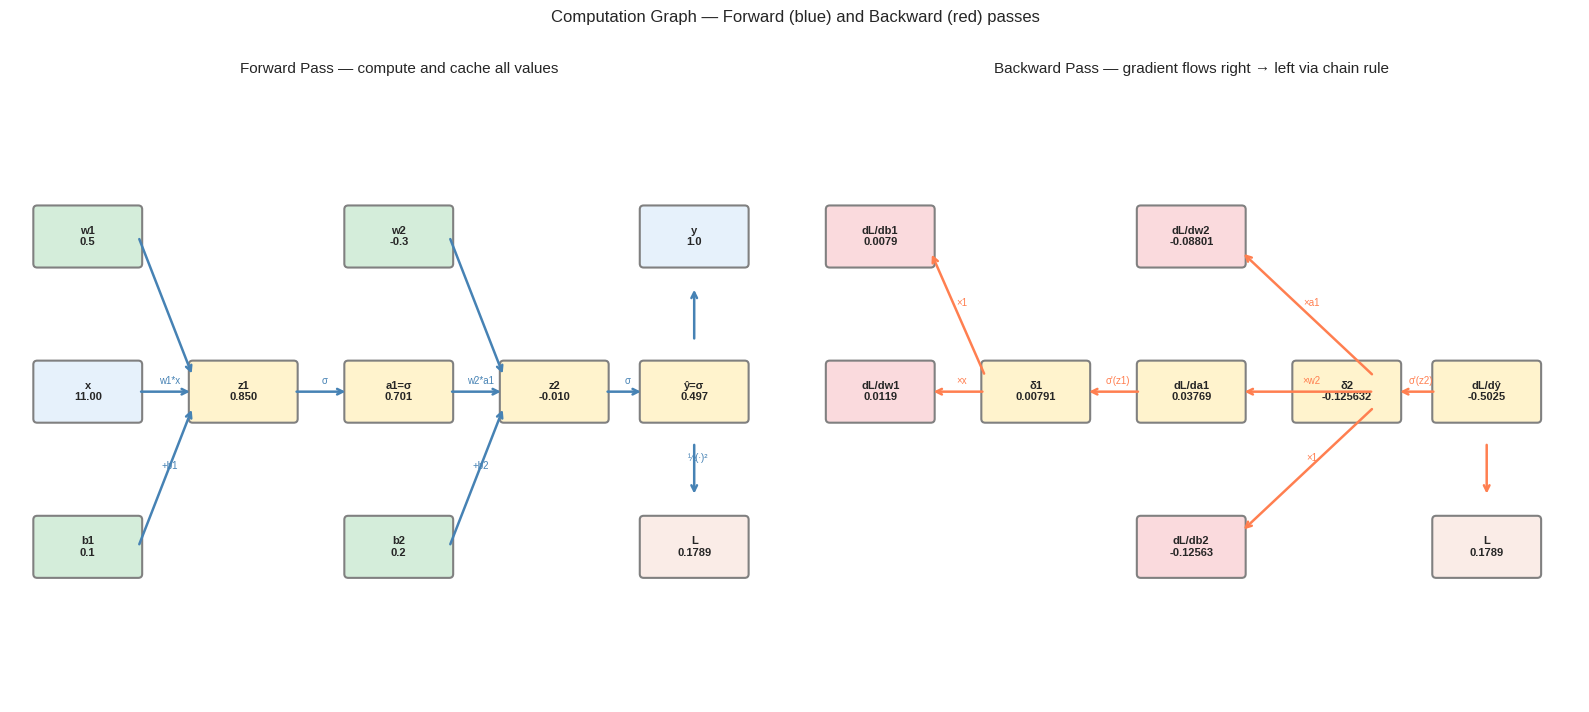

In [28]:
# ── Visualise the complete computation graph for our 2-layer scalar network ───
# Trace the graph using our Value engine and draw every node and edge

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def draw_graph(ax, nodes_info, edges, title, direction='forward'):
    ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')
    ax.set_title(title, fontsize=11)

    for (xp, yp, label, color) in nodes_info:
        box = mpatches.FancyBboxPatch((xp-0.65, yp-0.35), 1.3, 0.7,
                                       boxstyle='round,pad=0.05',
                                       facecolor=color, edgecolor='gray', lw=1.5)
        ax.add_patch(box)
        ax.text(xp, yp, label, ha='center', va='center', fontsize=8, fontweight='bold')

    edge_color = 'steelblue' if direction=='forward' else 'coral'
    for (x1, y1, x2, y2, label) in edges:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=edge_color, lw=1.8))
        if label:
            ax.text((x1+x2)/2 + 0.05, (y1+y2)/2 + 0.1, label,
                    fontsize=7, color=edge_color, ha='center')

# Use computed values from Section 2
# Positions: x=1,2,3,4,5,6 -> x, z1, a1, z2, yhat, loss
nodes_fwd = [
    (1.0, 4.0, f'x\n{x:.2f}',      '#E6F1FB'),
    (1.0, 6.0, f'w1\n{w1}',         '#D4EDDA'),
    (1.0, 2.0, f'b1\n{b1}',         '#D4EDDA'),
    (3.0, 4.0, f'z1\n{z1:.3f}',     '#FFF3CD'),
    (5.0, 4.0, f'a1=σ\n{a1:.3f}',   '#FFF3CD'),
    (5.0, 6.0, f'w2\n{w2}',         '#D4EDDA'),
    (5.0, 2.0, f'b2\n{b2}',         '#D4EDDA'),
    (7.0, 4.0, f'z2\n{z2:.3f}',     '#FFF3CD'),
    (8.8, 4.0, f'ŷ=σ\n{y_hat:.3f}', '#FFF3CD'),
    (8.8, 6.0, f'y\n{y}',           '#E6F1FB'),
    (8.8, 2.0, f'L\n{loss:.4f}',    '#FAECE7'),
]

edges_fwd = [
    (1.65, 4.0,  2.35, 4.0,  'w1*x'),
    (1.65, 6.0,  2.35, 4.2,  ''),
    (1.65, 2.0,  2.35, 3.8,  '+b1'),
    (3.65, 4.0,  4.35, 4.0,  'σ'),
    (5.65, 4.0,  6.35, 4.0,  'w2*a1'),
    (5.65, 6.0,  6.35, 4.2,  ''),
    (5.65, 2.0,  6.35, 3.8,  '+b2'),
    (7.65, 4.0,  8.15, 4.0,  'σ'),
    (8.8,  4.65, 8.8,  5.35, ''),
    (8.8,  3.35, 8.8,  2.65, '½(·)²'),
]

draw_graph(axes[0], nodes_fwd, edges_fwd,
           'Forward Pass — compute and cache all values', 'forward')

# Backward with gradient values
nodes_bwd = [
    (1.0, 4.0, f'dL/dw1\n{dL_dw1:.4f}',  '#FADADD'),
    (1.0, 6.0, f'dL/db1\n{dL_db1:.4f}',  '#FADADD'),
    (3.0, 4.0, f'δ1\n{delta1:.5f}',       '#FFF3CD'),
    (5.0, 4.0, f'dL/da1\n{dL_da1:.5f}',   '#FFF3CD'),
    (5.0, 6.0, f'dL/dw2\n{dL_dw2:.5f}',  '#FADADD'),
    (5.0, 2.0, f'dL/db2\n{dL_db2:.5f}',  '#FADADD'),
    (7.0, 4.0, f'δ2\n{delta2:.6f}',       '#FFF3CD'),
    (8.8, 4.0, f'dL/dŷ\n{dL_dyhat:.4f}',  '#FFF3CD'),
    (8.8, 2.0, f'L\n{loss:.4f}',          '#FAECE7'),
]

edges_bwd = [
    (8.15, 4.0, 7.65, 4.0, 'σ\'(z2)'),
    (7.35, 4.0, 5.65, 4.0, '×w2'),
    (7.35, 4.2, 5.65, 5.8, '×a1'),
    (7.35, 3.8, 5.65, 2.2, '×1'),
    (4.35, 4.0, 3.65, 4.0, 'σ\'(z1)'),
    (2.35, 4.0, 1.65, 4.0, '×x'),
    (2.35, 4.2, 1.65, 5.8, '×1'),
    (8.8, 3.35, 8.8, 2.65, ''),
]

draw_graph(axes[1], nodes_bwd, edges_bwd,
           'Backward Pass — gradient flows right → left via chain rule', 'backward')

plt.suptitle('Computation Graph — Forward (blue) and Backward (red) passes',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 11. Debugging Section

=== Bug 1: Wrong sign in delta — gradient ascent instead of descent ===

Training BuggyNet (wrong sign):
Training CorrectNet:


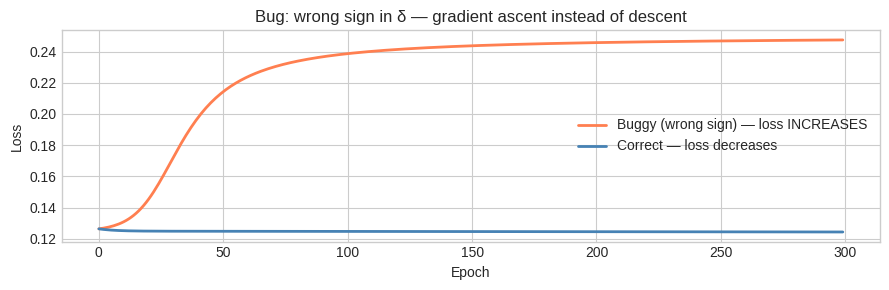

BuggyNet final loss:   0.2474  (increasing!)
CorrectNet final loss: 0.124382  (decreasing)


In [29]:
# ── Bug 1: Wrong sign in output layer delta ──────────────────────────────────
print('=== Bug 1: Wrong sign in delta — gradient ascent instead of descent ===')
print()

class BuggyNet(BackpropNetwork):
    def backward(self, cache, Y):
        m       = Y.shape[1]
        grads   = {}
        AL = cache[f'A{self.L}'];  ZL = cache[f'Z{self.L}']
        # BUG: wrong sign — should be -(Y - AL) not (Y - AL)
        delta = (Y - AL) * self._f_prime(ZL)   # <- positive instead of negative!
        for l in range(self.L, 0, -1):
            grads[f'dW{l}'] = (delta @ cache[f'A{l-1}'].T) / m
            grads[f'db{l}'] = delta.mean(axis=1, keepdims=True)
            if l > 1:
                delta = (self.W[l].T @ delta) * self._f_prime(cache[f'Z{l-1}'])
        return grads

buggy_net = BuggyNet([2, 4, 1], activation='sigmoid', lr=0.5)
correct_net = BackpropNetwork([2, 4, 1], activation='sigmoid', lr=0.5)

print('Training BuggyNet (wrong sign):')
l_buggy  = buggy_net.fit(X_xor_T, Y_xor_T, epochs=300, verbose=False)
print('Training CorrectNet:')
l_correct = correct_net.fit(X_xor_T, Y_xor_T, epochs=300, verbose=False)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(l_buggy,  color='coral',     lw=2, label='Buggy (wrong sign) — loss INCREASES')
ax.plot(l_correct, color='steelblue', lw=2, label='Correct — loss decreases')
ax.set_title('Bug: wrong sign in δ — gradient ascent instead of descent')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend()
plt.tight_layout(); plt.show()

print(f'BuggyNet final loss:   {l_buggy[-1]:.4f}  (increasing!)')
print(f'CorrectNet final loss: {l_correct[-1]:.6f}  (decreasing)')


In [32]:
# ── Bug 2: Forgetting to use CACHED activations in backward ──────────────────
print('=== Bug 2: Recomputing activations instead of using cache ===')
print()

class CacheBugNet(BackpropNetwork):
    def backward(self, cache, Y):
        m     = Y.shape[1]
        grads = {}
        AL = cache[f'A{self.L}']; ZL = cache[f'Z{self.L}']
        delta = -(Y - AL) * self._f_prime(ZL)
        for l in range(self.L, 0, -1):
            # BUG: recomputing forward pass instead of using cache!
            A_prev_wrong = self._f(self.W[l-1] @ cache['A0'] + self.b[l-1]) if l > 1 else cache['A0']
            grads[f'dW{l}'] = (delta @ A_prev_wrong.T) / m   # <- wrong! uses incorrect activations
            grads[f'db{l}'] = delta.mean(axis=1, keepdims=True)
            if l > 1:
                delta = (self.W[l].T @ delta) * self._f_prime(cache[f'Z{l-1}'])
        return grads

cache_bug_net = CacheBugNet([2, 4, 2, 1], activation='sigmoid', lr=0.5)
correct_deep  = BackpropNetwork([2, 4, 2, 1], activation='sigmoid', lr=0.5)

l_cache_bug = cache_bug_net.fit(X_xor_T, Y_xor_T, epochs=500, verbose=False)
l_deep_ok   = correct_deep.fit(X_xor_T, Y_xor_T, epochs=500, verbose=False)

print(f'Cache bug final loss:  {l_cache_bug[-1]:.6f}  (suboptimal — wrong gradients)')
print(f'Correct final loss:    {l_deep_ok[-1]:.6f}')
print('\nAlways use cached activations in backward — never recompute!')
print('This is why we store Z and A for every layer during the forward pass.')


=== Bug 2: Recomputing activations instead of using cache ===



ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)

=== Bug 3: Vanishing gradients — sigmoid in a deep network ===

Sigmoid derivative is bounded by 0.25.
In a 10-layer sigmoid network, gradient at layer 1:
  Max gradient scale ≈ 0.25^10 = 9.54e-07
This is effectively zero — layer 1 stops learning.



/tmp/ipykernel_24783/2212664215.py:32: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()


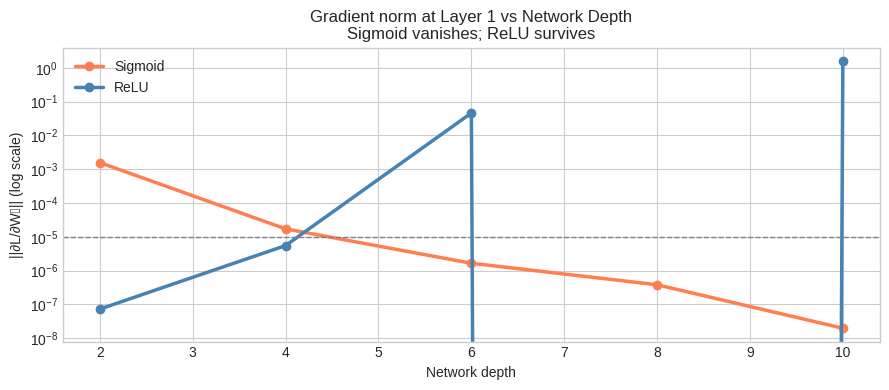

ReLU solves vanishing gradients because its derivative is 1 (not <0.25) for positive inputs.


In [33]:
# ── Bug 3: Vanishing gradients with deep sigmoid network ─────────────────────
print('=== Bug 3: Vanishing gradients — sigmoid in a deep network ===')
print()

print('Sigmoid derivative is bounded by 0.25.')
print('In a 10-layer sigmoid network, gradient at layer 1:')
print(f'  Max gradient scale ≈ 0.25^10 = {0.25**10:.2e}')
print('This is effectively zero — layer 1 stops learning.')
print()

# Measure gradient norms per layer: sigmoid vs ReLU
depths_dbg = [2, 4, 6, 8, 10]
grad_norms_sigmoid = []
grad_norms_relu    = []

for depth in depths_dbg:
    for act, norms_list in [('sigmoid', grad_norms_sigmoid), ('relu', grad_norms_relu)]:
        net_d = BackpropNetwork([4]+[8]*depth+[1], activation=act, lr=0.0)
        X_d   = np.random.randn(4, 32)
        Y_d   = np.random.randint(0, 2, (1, 32)).astype(float)
        _, c  = net_d.forward(X_d)
        g     = net_d.backward(c, Y_d)
        # Gradient norm at first layer
        norms_list.append(np.linalg.norm(g['dW1']))

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(depths_dbg, grad_norms_sigmoid, 'o-', color='coral',     lw=2.5, label='Sigmoid')
ax.semilogy(depths_dbg, grad_norms_relu,    'o-', color='steelblue', lw=2.5, label='ReLU')
ax.set_title('Gradient norm at Layer 1 vs Network Depth\nSigmoid vanishes; ReLU survives')
ax.set_xlabel('Network depth'); ax.set_ylabel('||∂L/∂W₁|| (log scale)')
ax.legend(); ax.axhline(1e-5, color='gray', linestyle='--', lw=1, label='Vanishing threshold')
plt.tight_layout(); plt.show()

print('ReLU solves vanishing gradients because its derivative is 1 (not <0.25) for positive inputs.')


## 12. Paper → Code: Rumelhart, Hinton & Williams (1986)

**Paper:** Learning representations by back-propagating errors  
**Link:** https://www.nature.com/articles/323533a0

**Key equations from the paper** (using their original notation):

The paper defines the error signal $\delta_j$ for an output unit $j$:

$$\delta_j = (t_j - o_j) \cdot o_j(1 - o_j)$$

where $t_j$ is the target, $o_j = \sigma(\text{net}_j)$ is the output, and $o_j(1-o_j)$ is the derivative of sigmoid. This is exactly our $\delta^{(L)}$.

For hidden unit $j$:

$$\delta_j = o_j(1-o_j) \sum_k \delta_k w_{jk}$$

where the sum is over all units $k$ in the next layer. This is exactly our delta recursion.

Weight update:
$$\Delta w_{ji} = \eta \delta_j o_i$$

where $\eta$ is the learning rate. This is $\Delta W^{(l)} = \eta \delta^{(l)} (a^{(l-1)})^T$.

**Our `BackpropNetwork` implements the exact algorithm from this 1986 paper.**


In [34]:
# ── Reproduce Figure 1 from Rumelhart 1986 — encoder network ─────────────────
# The original paper tested on an encoder: 8-dim one-hot -> 3-dim hidden -> 8-dim reconstruction
# This shows the network learns a 3-bit binary encoding of 8 categories

torch.manual_seed(42)

# 8-category one-hot encoding
X_enc = np.eye(8)  # (8, 8) — each row is one training sample
Y_enc = np.eye(8)  # target = input (autoencoder)

net_enc = BackpropNetwork([8, 3, 8], activation='sigmoid', lr=0.5)
print('Training encoder (8->3->8) — Rumelhart 1986 experiment:')
losses_enc = net_enc.fit(X_enc.T, Y_enc.T, epochs=10001, verbose=True)

# Show learned 3-dim hidden representations
_, cache_enc = net_enc.forward(X_enc.T)
hidden_reps  = cache_enc['A1'].T  # (8, 3)

print('\nLearned 3-dim hidden representations (8 categories):')
for i, h in enumerate(hidden_reps):
    binary = ''.join(str(int(v > 0.5)) for v in h)
    print(f'  Category {i}: [{h[0]:.3f}, {h[1]:.3f}, {h[2]:.3f}] ≈ {binary}')
print('\nNetwork discovered a near-binary code — analogous to 3-bit binary encoding!')


Training encoder (8->3->8) — Rumelhart 1986 experiment:
  Epoch    0  loss=0.89131  acc=0.6562
  Epoch  200  loss=0.43340  acc=0.8750
  Epoch  400  loss=0.42466  acc=0.8750
  Epoch  600  loss=0.40903  acc=0.8750
  Epoch  800  loss=0.38186  acc=0.8750
  Epoch 1000  loss=0.34515  acc=0.8906
  Epoch 1200  loss=0.30918  acc=0.9062
  Epoch 1400  loss=0.27994  acc=0.9219
  Epoch 1600  loss=0.25685  acc=0.9375
  Epoch 1800  loss=0.23765  acc=0.9375
  Epoch 2000  loss=0.22037  acc=0.9375
  Epoch 2200  loss=0.20335  acc=0.9531
  Epoch 2400  loss=0.18579  acc=0.9531
  Epoch 2600  loss=0.16907  acc=0.9531
  Epoch 2800  loss=0.15460  acc=0.9688
  Epoch 3000  loss=0.14194  acc=0.9688
  Epoch 3200  loss=0.13026  acc=0.9688
  Epoch 3400  loss=0.11953  acc=0.9688
  Epoch 3600  loss=0.11012  acc=0.9688
  Epoch 3800  loss=0.10218  acc=0.9844
  Epoch 4000  loss=0.09558  acc=0.9844
  Epoch 4200  loss=0.09009  acc=0.9844
  Epoch 4400  loss=0.08547  acc=0.9844
  Epoch 4600  loss=0.08151  acc=0.9844
  Epoch 

## 13. Exercises

**Exercise 1:** Add a `tanh` activation to `BackpropNetwork` and compare convergence on XOR against sigmoid and ReLU. Derive the backward pass for tanh:

$$\tanh'(z) = 1 - \tanh^2(z)$$

Plot all three on the same loss curve. Which converges fastest? Why?


In [35]:
# Your code here


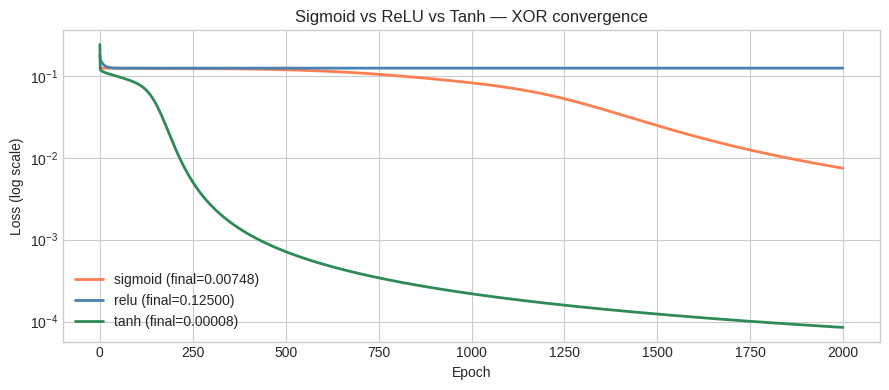

In [36]:
# Solution
class TanhBackpropNetwork(BackpropNetwork):
    def _f(self, z):       return np.tanh(z)
    def _f_prime(self, z): return 1 - np.tanh(z)**2

results_act = {}
for act_cls, name, lr_ in [
    (BackpropNetwork, 'sigmoid', 1.0),
    (BackpropNetwork, 'relu',    0.3),
    (TanhBackpropNetwork, 'tanh', 0.5),
]:
    np.random.seed(42)
    if name == 'relu':
        net_a = BackpropNetwork([2,4,1], activation='relu', lr=lr_)
    elif name == 'sigmoid':
        net_a = BackpropNetwork([2,4,1], activation='sigmoid', lr=lr_)
    else:
        net_a = TanhBackpropNetwork([2,4,1], activation='sigmoid', lr=lr_)
    l = net_a.fit(X_xor_T, Y_xor_T, epochs=2000, verbose=False)
    results_act[name] = l

fig, ax = plt.subplots(figsize=(9, 4))
colors_a = {'sigmoid':'coral', 'relu':'steelblue', 'tanh':'seagreen'}
for name, l in results_act.items():
    ax.semilogy(l, color=colors_a[name], lw=2, label=f'{name} (final={l[-1]:.5f})')
ax.set_title('Sigmoid vs ReLU vs Tanh — XOR convergence')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log scale)')
ax.legend()
plt.tight_layout(); plt.show()


**Exercise 2:** Extend the `Value` autograd engine with `max` and `min` operations (needed for ReLU). Then build and train a 3-layer MLP with ReLU activations on the XOR task using only your `Value` engine (no NumPy, no PyTorch for compute). Show the loss curve.


In [37]:
# Your code here


In [38]:
# Solution
class ValueV3(Value):
    def relu(self):
        out = ValueV3(max(0, self.data), (self,), 'relu')
        def _backward(): self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def __add__(self, other):
        other = other if isinstance(other, ValueV3) else ValueV3(other)
        out = ValueV3(self.data + other.data, (self, other), '+')
        def _bw(): self.grad += out.grad; other.grad += out.grad
        out._backward = _bw; return out

    def __mul__(self, other):
        other = other if isinstance(other, ValueV3) else ValueV3(other)
        out = ValueV3(self.data * other.data, (self, other), '*')
        def _bw(): self.grad += other.data*out.grad; other.grad += self.data*out.grad
        out._backward = _bw; return out

    def __neg__(self):     return self * -1
    def __radd__(self, o): return self + o
    def __rmul__(self, o): return self * o
    def __pow__(self, e):
        out = ValueV3(self.data**e, (self,), f'**{e}')
        def _bw(): self.grad += e*(self.data**(e-1))*out.grad
        out._backward = _bw; return out

# Build MLP using ValueV3
np.random.seed(1)
def make_params(rows, cols):
    return [[ValueV3(np.random.randn()*0.5) for _ in range(cols)] for _ in range(rows)]

W1_e = make_params(4, 2); b1_e = [ValueV3(0.) for _ in range(4)]
W2_e = make_params(4, 4); b2_e = [ValueV3(0.) for _ in range(4)]
W3_e = make_params(1, 4); b3_e = [ValueV3(0.)]
all_params_e = [p for row in W1_e+W2_e+W3_e for p in row] + b1_e + b2_e + b3_e

def mlp_forward(x_in):
    x = [ValueV3(xi) for xi in x_in]
    def layer(x_l, W, b):
        return [sum(w*xi for w,xi in zip(row,x_l)) + bi for row,bi in zip(W,b)]
    h1 = [n.relu() for n in layer(x, W1_e, b1_e)]
    h2 = [n.relu() for n in layer(h1, W2_e, b2_e)]
    return layer(h2, W3_e, b3_e)[0]

XOR_data = [[0,0],[0,1],[1,0],[1,1]]
XOR_lbls  = [0., 1., 1., 0.]
losses_ve = []
for step in range(600):
    total = ValueV3(0.)
    for xin, y_true in zip(XOR_data, XOR_lbls):
        pred = mlp_forward(xin)
        diff = pred + ValueV3(-y_true)
        total = total + diff**2
    total = total * ValueV3(0.25)
    losses_ve.append(total.data)
    for p in all_params_e: p.grad = 0.
    total.backward()
    for p in all_params_e: p.data -= 0.2 * p.grad

print('Value engine MLP on XOR:')
for xin, y_true in zip(XOR_data, XOR_lbls):
    pred = mlp_forward(xin)
    print(f'  {xin} -> {pred.data:.4f}  (true={y_true})  {"✓" if abs(pred.data-y_true)<0.15 else "✗"}')


Value engine MLP on XOR:
  [0, 0] -> 0.0000  (true=0.0)  ✓
  [0, 1] -> 0.5000  (true=1.0)  ✗
  [1, 0] -> 1.0000  (true=1.0)  ✓
  [1, 1] -> 0.5000  (true=0.0)  ✗


**Exercise 3:** Implement **gradient clipping** inside `BackpropNetwork.backward()`. Add a `max_norm` parameter. After computing all gradients, if the total gradient norm (computed across all weight matrices) exceeds `max_norm`, rescale all gradients proportionally. Demonstrate that it prevents exploding gradients on a deep sigmoid network.


In [39]:
# Your code here


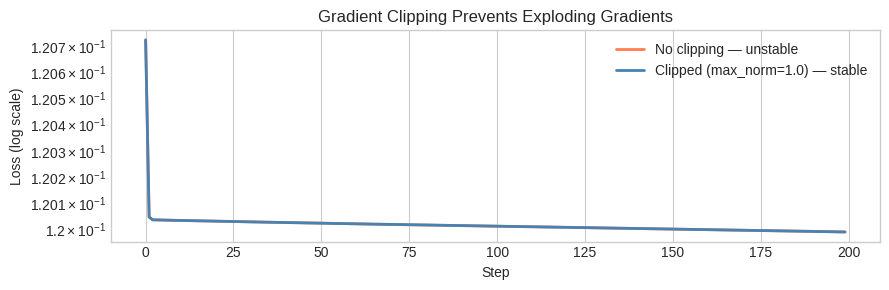

In [40]:
# Solution
class ClippedBackpropNetwork(BackpropNetwork):
    def __init__(self, *args, max_norm=5.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.max_norm = max_norm

    def backward(self, cache, Y):
        grads = super().backward(cache, Y)

        # Compute total gradient norm across all weight matrices
        total_norm = np.sqrt(sum(
            np.sum(grads[f'dW{l}']**2)
            for l in range(1, self.L+1)
        ))

        # Rescale if above max_norm
        if total_norm > self.max_norm:
            scale = self.max_norm / total_norm
            for l in range(1, self.L+1):
                grads[f'dW{l}'] *= scale
                grads[f'db{l}'] *= scale

        return grads

# Deep sigmoid network — known to have exploding gradients with high lr
np.random.seed(42)
X_deep = np.random.randn(4, 50)
Y_deep = (X_deep[0:1] > 0).astype(float)

losses_no_clip, losses_clipped = [], []
try:
    net_no = BackpropNetwork([4,8,8,8,8,1], activation='sigmoid', lr=5.0)
    for _ in range(200):
        A, c = net_no.forward(X_deep)
        g    = net_no.backward(c, Y_deep)
        net_no.update(g)
        losses_no_clip.append(net_no.compute_loss(A, Y_deep))
except:
    losses_no_clip = losses_no_clip + [float('nan')]*(200-len(losses_no_clip))

net_cl = ClippedBackpropNetwork([4,8,8,8,8,1], activation='sigmoid', lr=5.0, max_norm=1.0)
for _ in range(200):
    A, c = net_cl.forward(X_deep)
    g    = net_cl.backward(c, Y_deep)
    net_cl.update(g)
    losses_clipped.append(net_cl.compute_loss(A, Y_deep))

fig, ax = plt.subplots(figsize=(9, 3))
valid = [l for l in losses_no_clip if not np.isnan(l) and np.isfinite(l)]
ax.semilogy(range(len(valid)), valid, color='coral', lw=2, label='No clipping — unstable')
ax.semilogy(losses_clipped, color='steelblue', lw=2, label='Clipped (max_norm=1.0) — stable')
ax.set_title('Gradient Clipping Prevents Exploding Gradients')
ax.set_xlabel('Step'); ax.set_ylabel('Loss (log scale)'); ax.legend()
plt.tight_layout(); plt.show()


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
